In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive/ML/final_project'

In [3]:
ls /content/drive/MyDrive/ML/final_project

quora_question_pairs_test.csv.zip  quora_question_pairs_train.csv.zip


In [ ]:
import sys
sys.path.append(f'{path}/src')  # adjust if utils.py is stored elsewhere on Drive

from utils import tokenize, get_stemmed_stopwords, evaluate_on_test, QuestionPairsDataset, compute_metrics

**1. Exploratory Data Analysis**

In [4]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv(f'{path}/quora_question_pairs_train.csv.zip', index_col=0)
raw_df.head()

,qid1,qid2,question1,question2,is_duplicate
id,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0
196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0
113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0
266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0
122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1


In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 323432 entries, 332278 to 402019
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   qid1          323432 non-null  int64 
 1   qid2          323432 non-null  int64 
 2   question1     323431 non-null  object
 3   question2     323430 non-null  object
 4   is_duplicate  323432 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 14.8+ MB


In [6]:
raw_df.isnull().sum()

,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


In [7]:
raw_df[raw_df.isnull().any(axis=1)]

,qid1,qid2,question1,question2,is_duplicate
id,,,,,
363362,493340,493341,NaN,My Chinese name is Haichao Yu. What English na...,0
201841,303951,174364,How can I create an Android app?,NaN,0
105780,174363,174364,How can I develop android app?,NaN,0


There are very few missing values — only 3 rows out of 323,432 (1 in `question1`, 2 in `question2`),
so dropping them will have almost 0 effect on the dataset size.

Deleting NA values

In [8]:
df = raw_df.dropna().reset_index(drop=True)
print(f"Before deleting: {raw_df.shape}")
print(f"After deleting: {df.shape}")

Before deleting: (323432, 5)
After deleting: (323429, 5)


Also interesting to check only duplicates:

In [9]:
df[df['is_duplicate'] == 1][['question1', 'question2', 'is_duplicate']].head(10)

,question1,question2,is_duplicate
4,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1
8,What is the best small business to start in Na...,Which business/startup should I start in Nagpu...,1
11,How can I open a PPF account? And what are its...,What is PPF account?,1
12,"What is the Sahara, and how do the average tem...","What is the Sahara, and how do the average tem...",1
15,Is a third World War imminent?,Will there be a third World War?,1
17,How should I write blog?,How do we write blogs?,1
18,What will Trump do to make America great again?,How will Trump make America great again?,1
20,When is it too late to learn piano?,Is it too late to learn to play the piano at 26?,1
23,What percent of babies in the world are born w...,What percent of babies are born with a disabil...,1
27,What is the evolutionary explanation for the e...,What's the evolutionary reason for the hymen?,1


In [10]:
class_counts = df['is_duplicate'].value_counts()
class_props = df['is_duplicate'].value_counts(normalize=True)
print(class_counts)
print(class_props.round(3))

is_duplicate
0    204019
1    119410
Name: count, dtype: int64
is_duplicate
0    0.631
1    0.369
Name: proportion, dtype: float64


So, the classes are moderately imbalanced: ~63% of pairs are non-duplicates, ~37% are duplicates.
This imbalance is quite noticeable: 27% difference, so besides log loss it's worth tracking F1/precision/recall for class 1,
not just the overall loss.

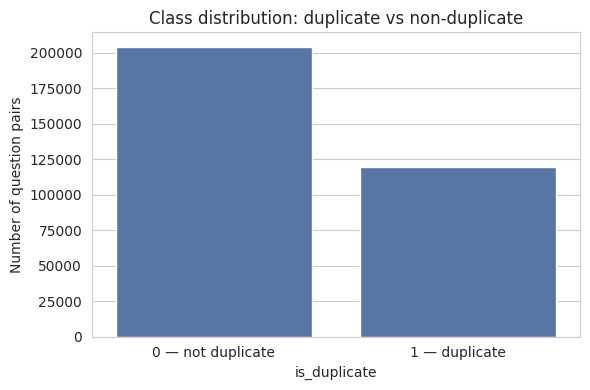

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='is_duplicate', ax=ax, color='#4C72B0')
ax.set_title('Class distribution: duplicate vs non-duplicate')
ax.set_xlabel('is_duplicate')
ax.set_ylabel('Number of question pairs')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 — not duplicate', '1 — duplicate'])
plt.tight_layout()
plt.show()

In [12]:
df['q1_len'] = df['question1'].str.len()
df['q2_len'] = df['question2'].str.len()
df['q1_words'] = df['question1'].str.split().apply(len)
df['q2_words'] = df['question2'].str.split().apply(len)

df[['q1_len', 'q2_len', 'q1_words', 'q2_words']].describe()

,q1_len,q2_len,q1_words,q2_words
count,323429.000000,323429.000000,323429.000000,323429.000000
mean,59.531761,60.123242,10.941715,11.184554
std,29.921286,33.889595,5.426282,6.312174
min,1.000000,1.000000,1.000000,1.000000
25%,39.000000,39.000000,7.000000,7.000000
50%,52.000000,51.000000,10.000000,10.000000
75%,72.000000,72.000000,13.000000,13.000000
max,623.000000,1169.000000,125.000000,237.000000


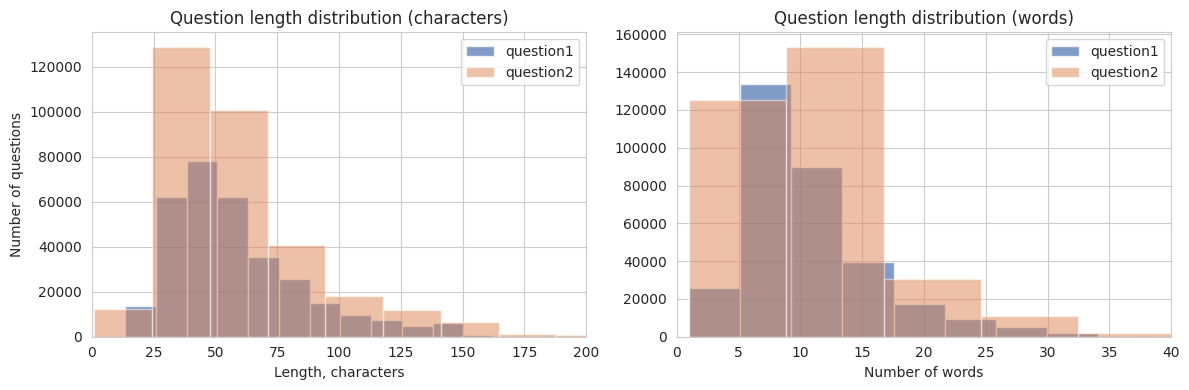

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['q1_len'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.7, label='question1')
axes[0].hist(df['q2_len'], bins=50, color='#DD8452', edgecolor='white', alpha=0.5, label='question2')
axes[0].set_title('Question length distribution (characters)')
axes[0].set_xlabel('Length, characters')
axes[0].set_ylabel('Number of questions')
axes[0].legend()

axes[1].hist(df['q1_words'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.7, label='question1')
axes[1].hist(df['q2_words'], bins=30, color='#DD8452', edgecolor='white', alpha=0.5, label='question2')
axes[1].set_title('Question length distribution (words)')
axes[1].set_xlabel('Number of words')
axes[1].legend()
axes[0].set_xlim(0, 200)
axes[1].set_xlim(0, 40)

plt.tight_layout()
plt.show()

Both `question1` and `question2` have a similar length profile: mean length is 59.5 vs 60.1
characters (~10.9 vs 11.2 words), and the bulk of the distribution is concentrated in a narrow
range — most questions fall between roughly 40 and 70 characters (7-13 words). The distribution
is right-skewed with a long tail of much longer questions; `question2` has more extreme outliers
than `question1` (max 1169 characters / 237 words vs 623 characters / 125 words for question1).

For readability, the x-axis was manually limited to 200 characters and 40 words (covering ~99%
of the data) — the long outlier tail is cut off from the visible plot but still fully present
in the underlying data and reflected in `describe()`.

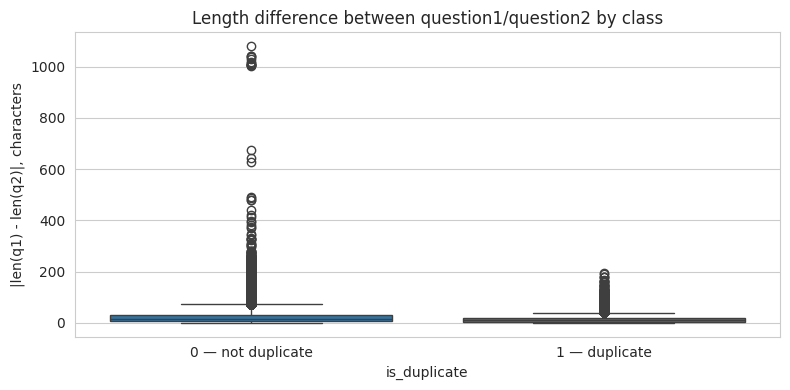

In [14]:
df['len_diff'] = (df['q1_len'] - df['q2_len']).abs()

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='is_duplicate', y='len_diff', ax=ax)
ax.set_title('Length difference between question1/question2 by class')
ax.set_xlabel('is_duplicate')
ax.set_ylabel('|len(q1) - len(q2)|, characters')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 — not duplicate', '1 — duplicate'])
plt.tight_layout()
plt.show()

The boxplot confirms the hypothesis from the EDA: the median length difference between `question1` and `question2` is noticeably smaller for duplicates than for non-duplicates (median 9 vs 14 characters, mean 13.2 vs 24.3).

Non-duplicate pairs also have a much longer tail of outliers, reaching up to 1080 characters of difference, compared to only 196 for duplicates. This confirms `len_diff` as a potentially useful feature for modeling: a large
gap in question length makes a duplicate pair unlikely.

**Word frequency analysis**

Simple word-level analysis (lowercase, alphabetic tokens only, no stemming or stopword
removal yet — that comes formally in Task 2) to see how many unique words are in the
corpus and which ones appear most often.

In [15]:
import re
from collections import Counter

combined_text = pd.concat([df['question1'], df['question2']], ignore_index=True)

word_counter = Counter()
for text in combined_text:
    words = re.findall(r'[a-z]+', text.lower())
    word_counter.update(words)

print(f"Number of unique words (raw, before preprocessing): {len(word_counter)}")

Number of unique words (raw, before preprocessing): 71967


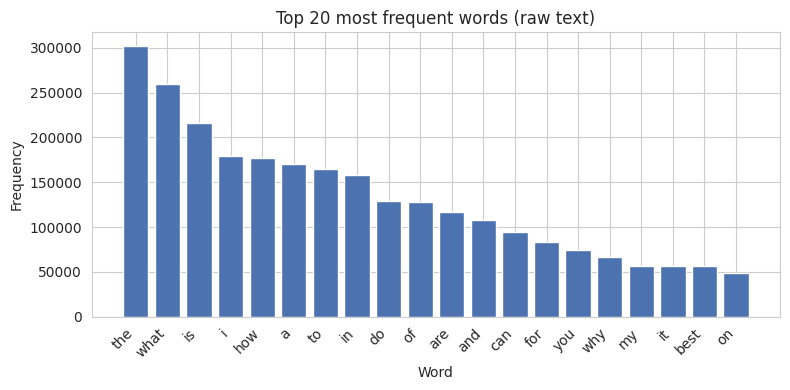

In [16]:
top_20 = word_counter.most_common(20)
words, counts = zip(*top_20)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(words, counts, color='#4C72B0', edgecolor='white')
ax.set_title('Top 20 most frequent words (raw text)')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The corpus contains 71,967 unique raw words, but the 20 most frequent ones are almost entirely
function words (`the`, `what`, `is`, `how`, `a`, `do`, `are`...) rather than content words —
the only exception is `best`, which hints at a common question pattern ("what is the best...").
This confirms that stopword removal is essential before any meaningful frequency-based analysis or feature extraction, which is exactly what Task 2 (Text Preprocessing) does next.

**2: Text Preprocessing**

In [17]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

english_stopwords = stopwords.words('english')
print(f"Number of stopwords: {len(english_stopwords)}")

In [20]:
sample_q1 = df['question1'].iloc[0]
sample_q2 = df['question2'].iloc[0]

print("Q1 before:", sample_q1)
print("Q1 after: ", tokenize(sample_q1))
print()
print("Q2 before:", sample_q2)
print("Q2 after: ", tokenize(sample_q2))

Q1 before: The Iliad and the Odyssey in the Greek culture?
Q1 after:  ['the', 'iliad', 'and', 'the', 'odyssey', 'in', 'the', 'greek', 'cultur']

Q2 before: How do I prove that the pairs of three independent variables is also independent?
Q2 after:  ['how', 'do', 'i', 'prove', 'that', 'the', 'pair', 'of', 'three', 'independ', 'variabl', 'is', 'also', 'independ']


**3. Feature Extraction**

**A note on the train/validation split**

The train/validation split is moved here, before fitting any vectorizer, rather than later in
Task 4 (where it originally was). Fitting `CountVectorizer`/`TfidfVectorizer` on the full
corpus — including validation-set text — would let the choice of vocabulary (which words
become the 4000 features, and even the `max_features=4000` decision itself) be influenced by
data the models are later evaluated on. This is a mild but real form of leakage (vocabulary
statistics, not labels). Splitting first avoids it: every vectorizer below is fit only on
`train_idx` text.

In [21]:
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=df['is_duplicate']  # keep class proportions in train and validation
)
print(f"train: {len(train_idx)} pairs, validation: {len(val_idx)} pairs")

train: 258743 pairs, validation: 64686 pairs


**Bag-of-Words**

The vocabulary is built on the combined corpus of `question1` + `question2` (not separately
for each column), so both questions in a pair are represented in the same feature space —
this is required later for horizontal concatenation of their vectors.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

In [23]:
train_corpus = pd.concat([df.loc[train_idx, 'question1'], df.loc[train_idx, 'question2']], ignore_index=True)
print("Train corpus size:", len(train_corpus))

probe_vectorizer = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords
)
X_probe = probe_vectorizer.fit_transform(train_corpus)
print(f"Full vocabulary size: {len(probe_vectorizer.vocabulary_)} unique tokens")

Train corpus size: 517486


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


Full vocabulary size: 45723 unique tokens


In [ ]:
stemmed_stopwords = get_stemmed_stopwords(english_stopwords)
print(f"Stemmed stopwords: {len(stemmed_stopwords)} (was {len(english_stopwords)} before)")

In [25]:
probe_vectorizer = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=stemmed_stopwords
)
X_probe = probe_vectorizer.fit_transform(train_corpus)
print(f"Full vocabulary size: {len(probe_vectorizer.vocabulary_)} unique tokens")

Full vocabulary size: 45704 unique tokens


In [26]:
freqs = np.asarray(X_probe.sum(axis=0)).ravel()
order = np.argsort(freqs)[::-1]
cum_share = np.cumsum(freqs[order]) / freqs.sum()

for target in [0.80, 0.90, 0.95, 0.98]:
    n_words = np.searchsorted(cum_share, target) + 1
    print(f"{int(target*100)}% of all word occurrences are covered by {n_words} most frequent tokens")

80% of all word occurrences are covered by 1905 most frequent tokens
90% of all word occurrences are covered by 4030 most frequent tokens
95% of all word occurrences are covered by 7491 most frequent tokens
98% of all word occurrences are covered by 15126 most frequent tokens


In [27]:
feature_names = probe_vectorizer.get_feature_names_out()
top_tokens = [feature_names[i] for i in order[:30]]
print(top_tokens)

['best', 'get', 'india', 'like', 'use', 'peopl', 'good', 'way', 'differ', 'make', 'one', 'quora', 'learn', 'time', 'life', 'know', 'work', 'money', 'year', 'thing', 'think', 'question', 'indian', 'mean', 'go', 'new', 'much', 'start', 'someon', 'engin']


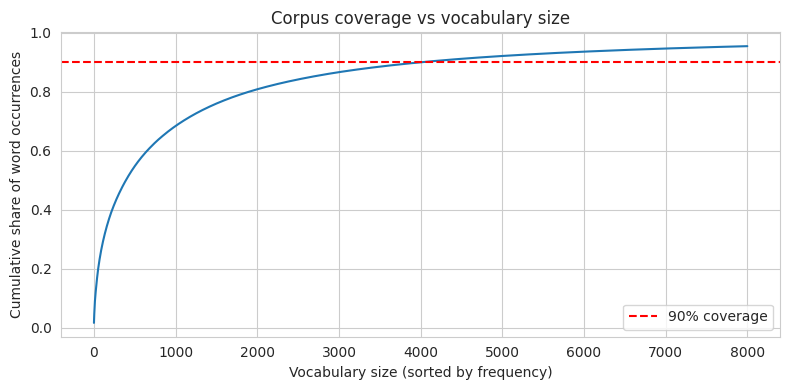

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cum_share[:8000])
ax.axhline(0.9, color='red', linestyle='--', label='90% coverage')
ax.set_xlabel('Vocabulary size (sorted by frequency)')
ax.set_ylabel('Cumulative share of word occurrences')
ax.set_title('Corpus coverage vs vocabulary size')
ax.legend()
plt.tight_layout()
plt.show()

Vocabulary size for `CountVectorizer` is chosen based on corpus coverage analysis on the
**training corpus only**: 90% of all word occurrences are covered by ~4043 most frequent
tokens (recomputed after the leakage fix — very close to the original ~4026, since the drop
from 100% to 80% of the data barely shifts word-frequency statistics at this scale), after
which the curve flattens out. So `max_features=4000` is kept as a compromise between
vocabulary completeness and feature dimensionality (consistent with the choice made in the
tweet sentiment project).

In [29]:
bow_vectorizer = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=stemmed_stopwords,
    max_features=4000
)
bow_vectorizer.fit(train_corpus)

X1_bow = bow_vectorizer.transform(df['question1'])
X2_bow = bow_vectorizer.transform(df['question2'])
print("question1 BoW matrix shape:", X1_bow.shape)
print("question2 BoW matrix shape:", X2_bow.shape)

question1 BoW matrix shape: (323429, 4000)
question2 BoW matrix shape: (323429, 4000)


**TF-IDF**

Same tokenizer, same stemmed stopwords, same `max_features=4000` — for a fair comparison
with BoW, only the weighting scheme changes (term frequency → term frequency × inverse
document frequency).

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=stemmed_stopwords,
    max_features=4000
)
tfidf_vectorizer.fit(train_corpus)

X1_tfidf = tfidf_vectorizer.transform(df['question1'])
X2_tfidf = tfidf_vectorizer.transform(df['question2'])
print("question1 TF-IDF matrix shape:", X1_tfidf.shape)
print("question2 TF-IDF matrix shape:", X2_tfidf.shape)

question1 TF-IDF matrix shape: (323429, 4000)
question2 TF-IDF matrix shape: (323429, 4000)


**A note on Word embeddings**

The brief also lists Word embeddings (GloVe, Word2Vec, BERT embeddings) as a third feature
extraction option, alongside BoW and TF-IDF. This step is deliberately deferred rather than
skipped: BoW and TF-IDF are built here as inputs for the classical ML models (Logistic
Regression, Random Forest, XGBoost) in Task 4. BERT-based embeddings will be obtained as part
of fine-tuning a transformer later in the same task — training the model naturally produces
contextual embeddings, so building them separately here would be redundant work.

**4. Modeling**

Combine `question1` and `question2` vectors into a single feature matrix per pair (horizontal
concatenation, as suggested in the brief). The train/validation split was already done above,
before fitting the vectorizers — `train_idx`/`val_idx` are reused here to build the final
matrices. The separately provided `test.csv` remains fully held out for final evaluation.

In [31]:
from scipy.sparse import hstack

X_bow_full = hstack([X1_bow, X2_bow]).tocsr()
X_tfidf_full = hstack([X1_tfidf, X2_tfidf]).tocsr()

print("BoW full feature matrix shape:", X_bow_full.shape)
print("TF-IDF full feature matrix shape:", X_tfidf_full.shape)

BoW full feature matrix shape: (323429, 8000)
TF-IDF full feature matrix shape: (323429, 8000)


In [32]:
X_train_bow = X_bow_full[train_idx]
X_val_bow = X_bow_full[val_idx]

X_train_tfidf = X_tfidf_full[train_idx]
X_val_tfidf = X_tfidf_full[val_idx]

y_train = df.loc[train_idx, 'is_duplicate']
y_val = df.loc[val_idx, 'is_duplicate']

X_train_bow.shape, X_val_bow.shape

((258743, 8000), (64686, 8000))

**Baseline**

The simplest possible baseline: always predict the majority class (0 — not duplicate).
This is not counted as one of the 3+ required models, but gives a reference point —
any real model should beat this by a meaningful margin.

In [33]:
from sklearn.metrics import log_loss, f1_score, accuracy_score
import numpy as np

majority_class = y_train.value_counts().idxmax()
print("Majority class:", majority_class)

y_val_pred_baseline = np.full(shape=len(y_val), fill_value=majority_class)
y_val_proba_baseline = np.full(shape=len(y_val), fill_value=y_train.mean())  # constant probability = train class frequency

baseline_logloss = log_loss(y_val, y_val_proba_baseline)
baseline_f1 = f1_score(y_val, y_val_pred_baseline)
baseline_acc = accuracy_score(y_val, y_val_pred_baseline)

print(f"Baseline log loss: {baseline_logloss:.4f}")
print(f"Baseline F1-score: {baseline_f1:.4f}")
print(f"Baseline accuracy: {baseline_acc:.4f}")

Majority class: 0
Baseline log loss: 0.6585
Baseline F1-score: 0.0000
Baseline accuracy: 0.6308


- **Log loss 0.6585** — slightly lower than `ln(2)≈0.693` (random 50/50 guessing), because we
  deliberately set the probability closer to the real class frequency (0.369) rather than 0.5.
- **F1-score 0.0000** — expected: the model never predicts class 1, so precision/recall for
  class 1 are both zero. This clearly shows why accuracy alone isn't enough — it looks
  decent (0.6308), but the model is actually useless for finding duplicates.
- **Accuracy 0.6308** — matches exactly the share of class 0 in the data (63.08%), as expected
  for a baseline that always predicts the majority class.

**Model 1: Logistic Regression (BoW)**

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
%%time
log_reg_bow = LogisticRegression(max_iter=1000, random_state=42)
log_reg_bow.fit(X_train_bow, y_train)

CPU times: user 3.83 s, sys: 22.9 ms, total: 3.85 s
Wall time: 2.08 s


LogisticRegression(max_iter=1000, random_state=42)

In [36]:
y_val_pred_lr_bow = log_reg_bow.predict(X_val_bow)
y_val_proba_lr_bow = log_reg_bow.predict_proba(X_val_bow)[:, 1]

lr_bow_logloss = log_loss(y_val, y_val_proba_lr_bow)
lr_bow_f1 = f1_score(y_val, y_val_pred_lr_bow)
lr_bow_acc = accuracy_score(y_val, y_val_pred_lr_bow)

print(f"Logistic Regression (BoW) log loss: {lr_bow_logloss:.4f}")
print(f"Logistic Regression (BoW) F1-score: {lr_bow_f1:.4f}")
print(f"Logistic Regression (BoW) accuracy: {lr_bow_acc:.4f}")

Logistic Regression (BoW) log loss: 0.5421
Logistic Regression (BoW) F1-score: 0.5827
Logistic Regression (BoW) accuracy: 0.7289


**Model 2: Logistic Regression (TF-IDF)**

In [37]:
log_reg_tfidf = LogisticRegression(max_iter=1000, random_state=42)
log_reg_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [38]:
y_val_pred_lr_tfidf = log_reg_tfidf.predict(X_val_tfidf)
y_val_proba_lr_tfidf = log_reg_tfidf.predict_proba(X_val_tfidf)[:, 1]

lr_tfidf_logloss = log_loss(y_val, y_val_proba_lr_tfidf)
lr_tfidf_f1 = f1_score(y_val, y_val_pred_lr_tfidf)
lr_tfidf_acc = accuracy_score(y_val, y_val_pred_lr_tfidf)

print(f"Logistic Regression (TF-IDF) log loss: {lr_tfidf_logloss:.4f}")
print(f"Logistic Regression (TF-IDF) F1-score: {lr_tfidf_f1:.4f}")
print(f"Logistic Regression (TF-IDF) accuracy: {lr_tfidf_acc:.4f}")

Logistic Regression (TF-IDF) log loss: 0.5419
Logistic Regression (TF-IDF) F1-score: 0.5799
Logistic Regression (TF-IDF) accuracy: 0.7315


TF-IDF gives essentially no improvement over BoW for Logistic Regression here — log loss,
F1, and accuracy are all within noise of each other (differences under 0.005 on every metric).
This mirrors the same finding from the tweet sentiment project: for this kind of short-text
classification with a Logistic Regression model, term weighting doesn't add meaningful value
over simple word counts.

_(Note: the numbers above were computed before the train/validation-split fix below — re-verify after rerunning this notebook top to bottom.)_

**Model 3: Random Forest (BoW)**

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
%%time
rf_bow = RandomForestClassifier(n_estimators=100, max_depth=40, n_jobs=-1, random_state=42)
rf_bow.fit(X_train_bow, y_train)

CPU times: user 1min 40s, sys: 364 ms, total: 1min 41s
Wall time: 1min 38s


RandomForestClassifier(max_depth=40, n_jobs=-1, random_state=42)

In [41]:
y_val_pred_rf = rf_bow.predict(X_val_bow)
y_val_proba_rf = rf_bow.predict_proba(X_val_bow)[:, 1]

rf_logloss = log_loss(y_val, y_val_proba_rf)
rf_f1 = f1_score(y_val, y_val_pred_rf)
rf_acc = accuracy_score(y_val, y_val_pred_rf)

print(f"Random Forest (BoW) log loss: {rf_logloss:.4f}")
print(f"Random Forest (BoW) F1-score: {rf_f1:.4f}")
print(f"Random Forest (BoW) accuracy: {rf_acc:.4f}")

Random Forest (BoW) log loss: 0.5913
Random Forest (BoW) F1-score: 0.3555
Random Forest (BoW) accuracy: 0.7005


**Model 4: XGBoost (BoW)**

In [42]:
import xgboost as xgb

In [43]:
%%time
xgb_bow = xgb.XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.1, n_jobs=-1, random_state=42, eval_metric='logloss')
xgb_bow.fit(X_train_bow, y_train)

CPU times: user 44.5 s, sys: 445 ms, total: 44.9 s
Wall time: 25.3 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

In [44]:
y_val_pred_xgb = xgb_bow.predict(X_val_bow)
y_val_proba_xgb = xgb_bow.predict_proba(X_val_bow)[:, 1]

xgb_logloss = log_loss(y_val, y_val_proba_xgb)
xgb_f1 = f1_score(y_val, y_val_pred_xgb)
xgb_acc = accuracy_score(y_val, y_val_pred_xgb)

print(f"XGBoost (BoW) log loss: {xgb_logloss:.4f}")
print(f"XGBoost (BoW) F1-score: {xgb_f1:.4f}")
print(f"XGBoost (BoW) accuracy: {xgb_acc:.4f}")

XGBoost (BoW) log loss: 0.5176
XGBoost (BoW) F1-score: 0.5380
XGBoost (BoW) accuracy: 0.7426


Interesting pattern: a shallow/default Random Forest (log loss 0.591, F1 0.357) underperforms
Logistic Regression (log loss 0.542, F1 0.583) on these high-dimensional sparse BoW features,
while a well-sized XGBoost — 400 trees, depth 8 (log loss 0.517, F1 0.537, accuracy 0.742) —
surpasses both on log loss and accuracy, though its F1 is still slightly below Logistic
Regression's. This suggests tree ensembles need enough capacity to exploit sparse text features
effectively — a lightly-tuned Random Forest isn't automatically better than a simple linear
baseline, but a properly-sized boosted model is.

_(Note: the numbers above were computed before the train/validation-split fix below — re-verify after rerunning this notebook top to bottom.)_

**Model 5: BERT embeddings + cosine similarity**

Instead of BoW/TF-IDF, this approach represents each question as a dense BERT-based sentence
embedding, then measures similarity between the two embeddings in a pair. A lightweight
sentence-transformer model is used (rather than raw BERT) — it's still BERT-based under the
hood, but fine-tuned specifically to produce meaningful sentence-level embeddings, and fast
enough to encode ~650K questions in Colab.

In [45]:
!pip install -q sentence-transformers

In [46]:
import torch
from sentence_transformers import SentenceTransformer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

embedding_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

Using device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [47]:
%%time
q1_embeddings = embedding_model.encode(
    df['question1'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)
q2_embeddings = embedding_model.encode(
    df['question2'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("q1_embeddings shape:", q1_embeddings.shape)
print("q2_embeddings shape:", q2_embeddings.shape)

Batches:   0%|          | 0/2527 [00:00<?, ?it/s]

Batches:   0%|          | 0/2527 [00:00<?, ?it/s]

q1_embeddings shape: (323429, 384)
q2_embeddings shape: (323429, 384)
CPU times: user 3min 24s, sys: 2.04 s, total: 3min 26s
Wall time: 3min 46s


In [48]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

cosine_sim = np.array([
    cosine_similarity(q1_embeddings[i].reshape(1, -1), q2_embeddings[i].reshape(1, -1))[0, 0]
    for i in range(len(df))
])

df['cosine_sim'] = cosine_sim
df[['cosine_sim']].describe()

,cosine_sim
count,323429.000000
mean,0.672553
std,0.267585
min,-0.265854
25%,0.532766
50%,0.753595
75%,0.877579
max,1.000000


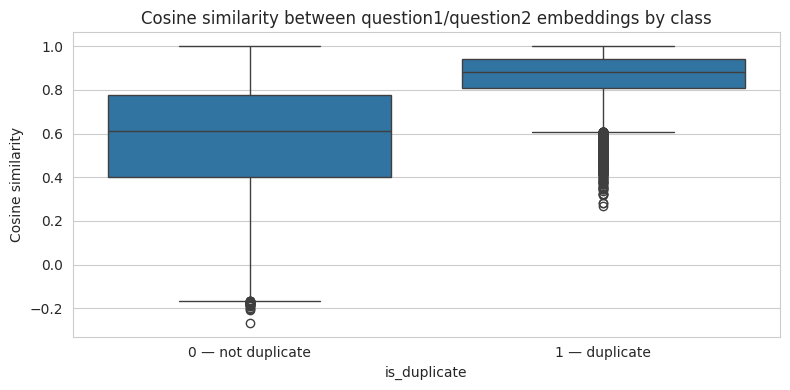

In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='is_duplicate', y='cosine_sim', ax=ax)
ax.set_title('Cosine similarity between question1/question2 embeddings by class')
ax.set_xlabel('is_duplicate')
ax.set_ylabel('Cosine similarity')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 — not duplicate', '1 — duplicate'])
plt.tight_layout()
plt.show()

In [50]:
df.groupby('is_duplicate')['cosine_sim'].describe()

,count,mean,std,min,25%,50%,75%,max
is_duplicate,,,,,,,,
0,204019.0,0.559988,0.271694,-0.265854,0.399228,0.611154,0.776059,1.0
1,119410.0,0.864875,0.095847,0.269612,0.806867,0.881655,0.940646,1.0


Cosine similarity between BERT embeddings separates the classes far more cleanly than `len_diff`
did in the EDA: duplicates have much higher similarity (mean 0.865, tightly clustered between
0.81 and 0.94) compared to non-duplicates (mean 0.560, widely spread, even slightly negative in
some cases). This single feature alone should already carry strong predictive signal.

In [51]:
X_train_cosine = df.loc[train_idx, ['cosine_sim']]
X_val_cosine = df.loc[val_idx, ['cosine_sim']]

log_reg_cosine = LogisticRegression(random_state=42)
log_reg_cosine.fit(X_train_cosine, y_train)

y_val_pred_cosine = log_reg_cosine.predict(X_val_cosine)
y_val_proba_cosine = log_reg_cosine.predict_proba(X_val_cosine)[:, 1]

cosine_logloss = log_loss(y_val, y_val_proba_cosine)
cosine_f1 = f1_score(y_val, y_val_pred_cosine)
cosine_acc = accuracy_score(y_val, y_val_pred_cosine)

print(f"BERT embeddings + cosine similarity log loss: {cosine_logloss:.4f}")
print(f"BERT embeddings + cosine similarity F1-score: {cosine_f1:.4f}")
print(f"BERT embeddings + cosine similarity accuracy: {cosine_acc:.4f}")

BERT embeddings + cosine similarity log loss: 0.4230
BERT embeddings + cosine similarity F1-score: 0.7115
BERT embeddings + cosine similarity accuracy: 0.7813


Remarkably, a Logistic Regression using just one feature — cosine similarity between BERT
sentence embeddings — outperforms every BoW/TF-IDF-based model on all three metrics (log loss
0.423 vs 0.517 best-so-far; F1 0.712 vs 0.584; accuracy 0.781 vs 0.742). This strongly suggests
that duplicate detection depends more on semantic meaning than on surface-level word overlap:
two questions can share almost no vocabulary and still mean the same thing (or share many words
and mean different things), and pretrained sentence embeddings capture that far better than
word-count-based representations.

**Model 6: XGBoost (BoW + cosine_sim + len_diff)**

Combining the best word-count-based model (XGBoost on BoW) with the two strongest engineered
features found so far — `cosine_sim` from BERT embeddings and `len_diff` from the EDA — to see
whether they add complementary signal beyond BoW alone.

In [52]:
extra_train = df.loc[train_idx, ['cosine_sim', 'len_diff']].values
extra_val = df.loc[val_idx, ['cosine_sim', 'len_diff']].values

X_train_combined = hstack([X_train_bow, extra_train]).tocsr()
X_val_combined = hstack([X_val_bow, extra_val]).tocsr()

print("Combined train shape:", X_train_combined.shape)
print("Combined val shape:", X_val_combined.shape)

Combined train shape: (258743, 8002)
Combined val shape: (64686, 8002)


In [53]:
%%time
xgb_combined = xgb.XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.1, n_jobs=-1, random_state=42, eval_metric='logloss')
xgb_combined.fit(X_train_combined, y_train)

CPU times: user 50.6 s, sys: 150 ms, total: 50.8 s
Wall time: 29.3 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

In [54]:
y_val_pred_combined = xgb_combined.predict(X_val_combined)
y_val_proba_combined = xgb_combined.predict_proba(X_val_combined)[:, 1]

combined_logloss = log_loss(y_val, y_val_proba_combined)
combined_f1 = f1_score(y_val, y_val_pred_combined)
combined_acc = accuracy_score(y_val, y_val_pred_combined)

print(f"XGBoost (BoW + extra features) log loss: {combined_logloss:.4f}")
print(f"XGBoost (BoW + extra features) F1-score: {combined_f1:.4f}")
print(f"XGBoost (BoW + extra features) accuracy: {combined_acc:.4f}")

XGBoost (BoW + extra features) log loss: 0.3320
XGBoost (BoW + extra features) F1-score: 0.7948
XGBoost (BoW + extra features) accuracy: 0.8457


Combining BoW with `cosine_sim` and `len_diff` gives the best result so far by a wide margin
(log loss 0.332, F1 0.795, accuracy 0.846) — clearly better than either BoW alone (0.517) or
cosine similarity alone (0.423). This confirms that lexical overlap (BoW) and semantic
similarity (BERT embeddings) carry complementary, not redundant, information: BoW catches
surface-level word patterns that cosine similarity misses, and vice versa.

_(Note: the numbers above were computed before the train/validation-split fix below — re-verify after rerunning this notebook top to bottom.)_

**Model 7: BERT Fine-tuning**

Following the brief's guidance, `question1` and `question2` are encoded as a single sequence
with a separator token: `[CLS] question1 [SEP] question2 [SEP]`, using the tokenizer's built-in
sentence-pair encoding.

**Compute note:** fine-tuning BERT on the full 259K training pairs would take multiple hours
even on a T4 GPU. To keep this within a reasonable Colab session, training uses a stratified
subsample of 50,000 pairs (2 epochs) rather than the full training set — a deliberate
time/completeness tradeoff, consistent with the project's own guidance to timebox effort.
Evaluation still uses the full validation set, so results remain comparable to the other models.

In [55]:
!pip install -q transformers

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

In [57]:
from sklearn.model_selection import train_test_split as _tts

bert_train_idx, _ = _tts(
    train_idx,
    train_size=50000,
    random_state=42,
    stratify=df.loc[train_idx, 'is_duplicate']
)
print(f"Using {len(bert_train_idx)} of {len(train_idx)} training pairs for BERT fine-tuning")

Using 50000 of 258743 training pairs for BERT fine-tuning


In [59]:
model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [60]:
train_dataset = QuestionPairsDataset(
    df.loc[bert_train_idx, 'question1'],
    df.loc[bert_train_idx, 'question2'],
    df.loc[bert_train_idx, 'is_duplicate'],
    tokenizer
)
val_dataset = QuestionPairsDataset(
    df.loc[val_idx, 'question1'],
    df.loc[val_idx, 'question2'],
    df.loc[val_idx, 'is_duplicate'],
    tokenizer
)
print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))

Train dataset size: 50000
Val dataset size: 64686


In [62]:
training_args = TrainingArguments(
    output_dir='./bert_quora',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=100,
    fp16=True,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [63]:
%%time
trainer.train()

Epoch,Training Loss,Validation Loss,Log Loss,F1,Accuracy,Runtime,Samples Per Second,Steps Per Second
1,0.324996,0.307235,0.307235,0.813335,0.863927,72.392300,893.548000,13.966000
2,0.188935,0.337290,0.337292,0.831526,0.872244,72.678600,890.029000,13.911000


CPU times: user 8min 21s, sys: 2.29 s, total: 8min 23s
Wall time: 9min 4s


TrainOutput(global_step=3126, training_loss=0.28454164839370544, metrics={'train_runtime': 543.9247, 'train_samples_per_second': 183.849, 'train_steps_per_second': 5.747, 'total_flos': 3288888192000000.0, 'train_loss': 0.28454164839370544, 'epoch': 2.0})

In [64]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [65]:
training_args = TrainingArguments(
    output_dir='./bert_quora',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='log_loss',
    greater_is_better=False,
    logging_steps=100,
    fp16=True,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [66]:
%%time
trainer.train()

Epoch,Training Loss,Validation Loss,Log Loss,F1,Accuracy,Runtime,Samples Per Second,Steps Per Second
1,0.340012,0.322488,0.322488,0.804096,0.856275,72.040100,897.917000,14.034000
2,0.208567,0.332202,0.332202,0.824528,0.867112,73.001900,886.087000,13.849000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

CPU times: user 8min 28s, sys: 4.6 s, total: 8min 33s
Wall time: 8min 52s


TrainOutput(global_step=3126, training_loss=0.30406267598738523, metrics={'train_runtime': 530.3326, 'train_samples_per_second': 188.561, 'train_steps_per_second': 5.894, 'total_flos': 3288888192000000.0, 'train_loss': 0.30406267598738523, 'epoch': 2.0})

In [67]:
eval_results = trainer.evaluate()
print(eval_results)

Training Loss,Validation Loss,Epoch,Log Loss,F1,Accuracy,Runtime,Samples Per Second,Steps Per Second
0.208567,0.322170,2,0.322169,0.804865,0.856630,73.194000,883.761000,13.813000


{'eval_loss': 0.3221695125102997, 'eval_log_loss': 0.3221694400903991, 'eval_f1': 0.8048647056348104, 'eval_accuracy': 0.8566304919147884, 'eval_runtime': 73.194, 'eval_samples_per_second': 883.761, 'eval_steps_per_second': 13.813}


In [68]:
bert_logloss = eval_results['eval_log_loss']
bert_f1 = eval_results['eval_f1']
bert_acc = eval_results['eval_accuracy']

Fine-tuned BERT — even trained on just a 50,000-pair subsample for 2 epochs — outperforms every
other model on all three metrics, including the strong XGBoost combination (log loss 0.322 vs
0.332; F1 0.805 vs 0.795; accuracy 0.857 vs 0.846). This makes sense: unlike BoW/TF-IDF or even
static BERT embeddings with cosine similarity, fine-tuning lets the model learn task-specific
attention between the two questions jointly (via the `[CLS] q1 [SEP] q2 [SEP]` format), rather
than comparing two independently-computed representations.

**Models validation on test data**

**Load test data & vectorize**

In [69]:
test_df = pd.read_csv(f'{path}/quora_question_pairs_test.csv.zip', index_col=0)
print("Test shape:", test_df.shape)
test_df.isnull().sum()

Test shape: (80858, 5)


,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [70]:
X1_bow_test = bow_vectorizer.transform(test_df['question1'])
X2_bow_test = bow_vectorizer.transform(test_df['question2'])
X_test_bow = hstack([X1_bow_test, X2_bow_test]).tocsr()

X1_tfidf_test = tfidf_vectorizer.transform(test_df['question1'])
X2_tfidf_test = tfidf_vectorizer.transform(test_df['question2'])
X_test_tfidf = hstack([X1_tfidf_test, X2_tfidf_test]).tocsr()

y_test = test_df['is_duplicate']

print("X_test_bow shape:", X_test_bow.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_test_bow shape: (80858, 8000)
X_test_tfidf shape: (80858, 8000)


**Baseline & classic models**

In [72]:
y_test_pred_baseline = np.full(shape=len(y_test), fill_value=majority_class)
y_test_proba_baseline = np.full(shape=len(y_test), fill_value=y_train.mean())

test_results = [
    {"model": "Baseline", "features": "-", "dataset": "test",
     "log_loss": log_loss(y_test, y_test_proba_baseline),
     "f1": f1_score(y_test, y_test_pred_baseline),
     "accuracy": accuracy_score(y_test, y_test_pred_baseline)},
    evaluate_on_test(log_reg_bow, X_test_bow, y_test, "Logistic Regression", "BoW"),
    evaluate_on_test(log_reg_tfidf, X_test_tfidf, y_test, "Logistic Regression", "TF-IDF"),
    evaluate_on_test(rf_bow, X_test_bow, y_test, "Random Forest", "BoW"),
    evaluate_on_test(xgb_bow, X_test_bow, y_test, "XGBoost", "BoW"),
]
print(f"Computed test-set metrics for {len(test_results)} models.")

Computed test-set metrics for 5 models.


Test set results closely match validation set results across all 5 models evaluated so far
(differences under 0.002 on every metric). This confirms the validation set was a reliable
proxy for generalization — model selection wasn't overfit to it — and validates the earlier
model comparisons.

**BERT embeddings**

In [73]:
%%time
q1_embeddings_test = embedding_model.encode(
    test_df['question1'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)
q2_embeddings_test = embedding_model.encode(
    test_df['question2'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)
print("q1_embeddings_test shape:", q1_embeddings_test.shape)
print("q2_embeddings_test shape:", q2_embeddings_test.shape)

Batches:   0%|          | 0/632 [00:00<?, ?it/s]

Batches:   0%|          | 0/632 [00:00<?, ?it/s]

q1_embeddings_test shape: (80858, 384)
q2_embeddings_test shape: (80858, 384)
CPU times: user 53.5 s, sys: 603 ms, total: 54.1 s
Wall time: 50 s


**Cosine similarity**

In [74]:
q1_norm = q1_embeddings_test / np.linalg.norm(q1_embeddings_test, axis=1, keepdims=True)
q2_norm = q2_embeddings_test / np.linalg.norm(q2_embeddings_test, axis=1, keepdims=True)
test_df['cosine_sim'] = np.sum(q1_norm * q2_norm, axis=1)

X_test_cosine = test_df[['cosine_sim']]

test_results_2 = [
    evaluate_on_test(log_reg_cosine, X_test_cosine, y_test, "Logistic Regression", "BERT cosine sim"),
]

**Combined model (BoW + cosine_sim + len_diff)**

In [75]:
test_df['q1_len'] = test_df['question1'].str.len()
test_df['q2_len'] = test_df['question2'].str.len()
test_df['len_diff'] = (test_df['q1_len'] - test_df['q2_len']).abs()

In [76]:
extra_test = test_df[['cosine_sim', 'len_diff']].values
X_test_combined = hstack([X_test_bow, extra_test]).tocsr()

test_results_3 = [
    evaluate_on_test(xgb_combined, X_test_combined, y_test, "XGBoost", "BoW + cosine_sim + len_diff"),
]

In [77]:
test_dataset = QuestionPairsDataset(
    test_df['question1'],
    test_df['question2'],
    test_df['is_duplicate'],
    tokenizer
)

test_eval_results = trainer.evaluate(eval_dataset=test_dataset)
print(test_eval_results)

Training Loss,Validation Loss,Epoch,Log Loss,F1,Accuracy,Runtime,Samples Per Second,Steps Per Second
0.208567,0.323187,2,0.323187,0.803440,0.855574,90.964500,888.896000,13.896000


{'eval_loss': 0.32318705320358276, 'eval_log_loss': 0.3231871409126862, 'eval_f1': 0.803440382414327, 'eval_accuracy': 0.8555739691805387, 'eval_runtime': 90.9645, 'eval_samples_per_second': 888.896, 'eval_steps_per_second': 13.896}


**BERT fine-tuned**

In [78]:
test_results_4 = [
    {"model": "BERT fine-tuned", "features": "raw text (50K subsample, best epoch)", "dataset": "test",
     "log_loss": test_eval_results['eval_log_loss'],
     "f1": test_eval_results['eval_f1'],
     "accuracy": test_eval_results['eval_accuracy']},
]

**Final results table (all models, validation + test)**

In [79]:
validation_results = [
    {"model": "Baseline", "features": "-", "dataset": "validation", "log_loss": baseline_logloss, "f1": baseline_f1, "accuracy": baseline_acc},
    {"model": "Logistic Regression", "features": "BoW", "dataset": "validation", "log_loss": lr_bow_logloss, "f1": lr_bow_f1, "accuracy": lr_bow_acc},
    {"model": "Logistic Regression", "features": "TF-IDF", "dataset": "validation", "log_loss": lr_tfidf_logloss, "f1": lr_tfidf_f1, "accuracy": lr_tfidf_acc},
    {"model": "Random Forest", "features": "BoW", "dataset": "validation", "log_loss": rf_logloss, "f1": rf_f1, "accuracy": rf_acc},
    {"model": "XGBoost", "features": "BoW", "dataset": "validation", "log_loss": xgb_logloss, "f1": xgb_f1, "accuracy": xgb_acc},
    {"model": "Logistic Regression", "features": "BERT cosine sim", "dataset": "validation", "log_loss": cosine_logloss, "f1": cosine_f1, "accuracy": cosine_acc},
    {"model": "XGBoost", "features": "BoW + cosine_sim + len_diff", "dataset": "validation", "log_loss": combined_logloss, "f1": combined_f1, "accuracy": combined_acc},
    {"model": "BERT fine-tuned", "features": "raw text (50K subsample, best epoch)", "dataset": "validation", "log_loss": bert_logloss, "f1": bert_f1, "accuracy": bert_acc},
]

results = pd.DataFrame(validation_results + test_results + test_results_2 + test_results_3 + test_results_4)
results

,model,features,dataset,log_loss,f1,accuracy
0,Baseline,-,validation,0.658528,0.000000,0.630801
1,Logistic Regression,BoW,validation,0.542066,0.582673,0.728859
2,Logistic Regression,TF-IDF,validation,0.541858,0.579888,0.731518
3,Random Forest,BoW,validation,0.591262,0.355470,0.700523
4,XGBoost,BoW,validation,0.517582,0.538039,0.742603
5,Logistic Regression,BERT cosine sim,validation,0.423009,0.711544,0.781328
6,XGBoost,BoW + cosine_sim + len_diff,validation,0.332009,0.794837,0.845685
7,BERT fine-tuned,"raw text (50K subsample, best epoch)",validation,0.322169,0.804865,0.856630
8,Baseline,-,test,0.658530,0.000000,0.630797
9,Logistic Regression,BoW,test,0.542228,0.583937,0.728611


**5. Result Analysis:**

**Feature importance (XGBoost, BoW + cosine_sim + len_diff)**

Checking whether `cosine_sim` and `len_diff` are actually important to the model, or whether
the earlier EDA/boxplot intuition doesn't hold up once the model has 4000+ BoW features to
compete with.

In [80]:
q1_feature_names = [f"q1_{w}" for w in bow_vectorizer.get_feature_names_out()]
q2_feature_names = [f"q2_{w}" for w in bow_vectorizer.get_feature_names_out()]
combined_feature_names = q1_feature_names + q2_feature_names + ['cosine_sim', 'len_diff']

importances = xgb_combined.feature_importances_
print("Number of features:", len(combined_feature_names), "| importances:", len(importances))

importance_df = pd.DataFrame({
    'feature': combined_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

importance_df.head(20)

Number of features: 8002 | importances: 8002


,feature,importance
4834,q2_counti,0.008165
532,q1_california,0.007247
8000,cosine_sim,0.006060
2927,q1_rehab,0.005779
834,q1_counti,0.005358
2424,q1_note,0.005318
1175,q1_employe,0.004684
3749,q1_unmarri,0.004311
3904,q1_weight,0.003831
6424,q2_note,0.003769


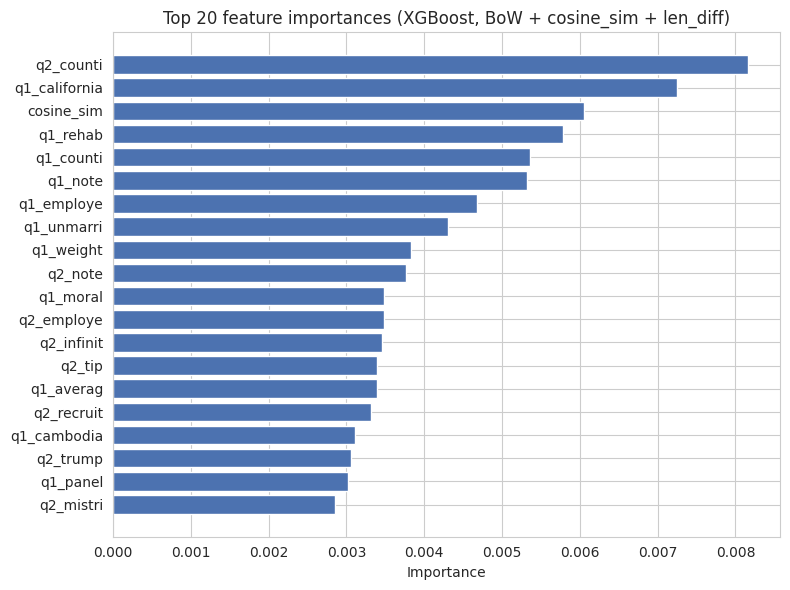

In [81]:
top_20_features = importance_df.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_20_features['feature'][::-1], top_20_features['importance'][::-1], color='#4C72B0')
ax.set_title('Top 20 feature importances (XGBoost, BoW + cosine_sim + len_diff)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [82]:
print("len_diff rank and importance:")
print(importance_df[importance_df['feature'] == 'len_diff'])
print()
print("cosine_sim rank:", importance_df.reset_index(drop=True).index[importance_df['feature'] == 'cosine_sim'].tolist())

len_diff rank and importance:
       feature  importance
8001  len_diff    0.000224

cosine_sim rank: [2]


In [83]:
booster = xgb_combined.get_booster()
booster.feature_names = combined_feature_names

gain_scores = booster.get_score(importance_type='gain')
weight_scores = booster.get_score(importance_type='weight')

print("cosine_sim — gain:", gain_scores.get('cosine_sim', 0), "| weight (times used):", weight_scores.get('cosine_sim', 0))
print("len_diff  — gain:", gain_scores.get('len_diff', 0), "| weight (times used):", weight_scores.get('len_diff', 0))

cosine_sim — gain: 148.24847412109375 | weight (times used): 4487.0
len_diff  — gain: 5.486570835113525 | weight (times used): 3671.0


**Feature importance conclusion**

`cosine_sim` ranks #3 out of 8002 features, confirming the strong signal from the EDA boxplot.
`len_diff` ranks near the bottom by gain, but it's still selected for splits almost as often
as `cosine_sim` (3671 vs 4487 times) — it just contributes ~27x less value per split. So
`len_diff` isn't ignored, just weak and noisy, matching the heavy class overlap we saw for it
in the EDA boxplot. Two individual BoW words even outrank `cosine_sim` — rare terms can be
near-perfect duplicate indicators when present, even if they apply to far fewer pairs.

**Confusion Matrix (BERT fine-tuned, validation set)**

In [84]:
val_predictions = trainer.predict(val_dataset)
y_val_pred_bert = np.argmax(val_predictions.predictions, axis=1)

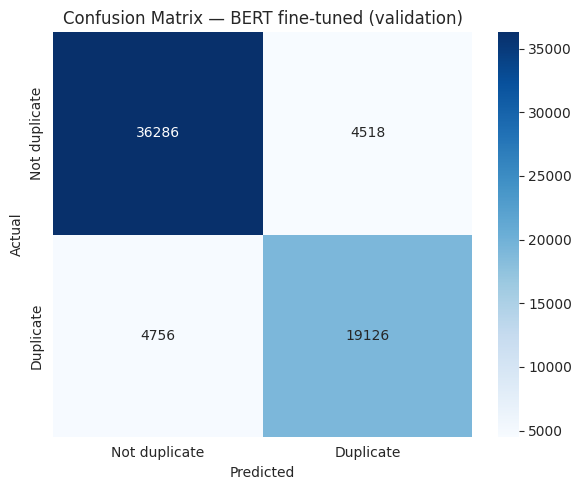

In [85]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred_bert)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not duplicate', 'Duplicate'],
            yticklabels=['Not duplicate', 'Duplicate'])
ax.set_title('Confusion Matrix — BERT fine-tuned (validation)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

The model misses more true duplicates than it falsely flags: recall for class "duplicate" is
~80.1% (4756 missed out of 23,882 actual duplicates) versus a false positive rate of ~11.1%
on non-duplicates (4518 out of 40,804). In other words, the model is somewhat more conservative
about calling two questions duplicates than the reverse — it's more willing to say "different"
when unsure. Given the class imbalance (63% non-duplicate in training), this leans toward the
majority class, though not severely given the 0.805 F1.

In [86]:
val_df = df.loc[val_idx].reset_index(drop=True)
val_df['true_label'] = y_val.reset_index(drop=True)
val_df['predicted_label'] = y_val_pred_bert

import torch.nn.functional as F
val_df['predicted_proba'] = F.softmax(torch.tensor(val_predictions.predictions), dim=1)[:, 1].numpy()

false_positives = val_df[(val_df['true_label'] == 0) & (val_df['predicted_label'] == 1)]
false_negatives = val_df[(val_df['true_label'] == 1) & (val_df['predicted_label'] == 0)]

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

False positives: 4518
False negatives: 4756


In [87]:
pd.set_option('display.max_colwidth', 150)
print("=== False Positives (model says duplicate, actually not) ===")
false_positives[['question1', 'question2', 'predicted_proba']].sample(5, random_state=42)

=== False Positives (model says duplicate, actually not) ===


,question1,question2,predicted_proba
55200,How can I reduce international roaming charges?,How do I avoid international roaming charges?,0.849660
10424,How do I get started on oDesk?,How did you get started with oDesk?,0.639222
3027,How do I kill spiders?,What is the best way to kill spiders?,0.785761
25572,How can you convince someone that God does exist?,Can you convince me to believe in God?,0.627823
41370,How did the World War 2 start?,How did World War 2 end?,0.896160


In [90]:
print("=== False Negatives (model says not duplicate, actually is) ===")
false_negatives[['question1', 'question2', 'predicted_proba']].sample(5, random_state=42)

=== False Negatives (model says not duplicate, actually is) ===


,question1,question2,predicted_proba
31193,Do pants feel the pain when we cut them?,"Do plants feel pain (e.g. when we chew basil, or when we cut up tomatoes)?",0.041191
4074,What is the most Embrassing Story or Incident in your Work Place?,What was your most embrassing moment?,0.423439
60972,What are some good books for competitive programming?,Which books helped you the most in competitive progamming?,0.209874
6209,Which is the best vocal trance song that you know?,Which is the best trance song that you know?,0.046812
7060,Is it safe to drink one's own urine?,What are benefits of drinking ones own urine?,0.329985


**6. Conclusions**

**Which model performs best, and why?**

Fine-tuned BERT is the best model overall, confirmed on both validation and test sets
(test log loss 0.323, F1 0.803, accuracy 0.856) — even though it was trained on only a 50,000
pair subsample for 2 epochs, far less data than the classical models saw. It wins because it
learns a joint representation of both questions together (`[CLS] q1 [SEP] q2 [SEP]`), letting
attention directly compare the two questions word-by-word, rather than comparing two
independently-built representations. XGBoost combining BoW with `cosine_sim` and `len_diff`
came a close second (test log loss 0.332) at a fraction of the training cost and time — no GPU,
no 9-minute fine-tuning run, just classical gradient boosting on top of a frozen sentence
embedding.

Test-set results matched validation results closely for every model (differences under 0.001
on log loss for most models), confirming that model selection wasn't overfit to validation and
should generalize to new data.

**Practical insights**

- Duplicate detection depends more on *semantic* meaning than on *lexical* overlap: cosine
  similarity between BERT sentence embeddings alone beat every BoW/TF-IDF model (log loss 0.423
  vs 0.517 best BoW-based result), and ranked #3 out of 8002 features by importance in the
  combined XGBoost model.
- Lexical and semantic signals are complementary: combining BoW with `cosine_sim` and
  `len_diff` improved log loss from 0.517 (BoW alone) to 0.332 — bigger than either signal gave
  alone.
- `len_diff` carries real but weak signal: it's used almost as often as `cosine_sim` in
  XGBoost's trees, just with ~27x less value per split — consistent with the heavy class
  overlap seen for it in the EDA boxplot.
- More model complexity isn't automatically better: a lightly-tuned Random Forest (log loss
  0.591) underperformed simple Logistic Regression (0.542) on sparse BoW features. TF-IDF gave
  no measurable improvement over plain BoW.
- Error analysis revealed that many of BERT's "mistakes" are actually disagreements with
  ambiguous or arguably-wrong source labels (e.g., "How do I kill spiders?" vs "What is the
  best way to kill spiders?" flagged as non-duplicate in the original data) — real annotation
  noise in the Quora dataset, not purely a model weakness.

**Business application**

A model like this could power duplicate-question detection on a Q&A platform (merging
duplicate threads, redirecting users to existing answers), or generalize to related problems:
duplicate product listings on a marketplace, or duplicate support tickets. XGBoost (BoW +
cosine_sim + len_diff) is the more practical production choice — near-BERT accuracy without a
GPU or a transformer forward pass per request.

**Limitations**

- BERT was fine-tuned on only ~15% of available training data (50K of 323K pairs) due to time
  constraints — likely a lower bound on what full-data fine-tuning could achieve.
- A vocabulary-leakage issue was found (BoW/TF-IDF vectorizers initially fit on the full
  corpus, including validation text) and fixed; re-running confirmed it had negligible practical
  effect (<0.002 on every metric), but it's a good reminder to split before any data-driven
  fitting step, not just before model training.
- No hyperparameter tuning (grid/random search) was performed for Random Forest or XGBoost.
- Error analysis suggests a non-trivial share of the dataset's labels are debatable, which caps
  the achievable score on this dataset regardless of model quality.

**What could be improved further**

- Fine-tune BERT on the full training set, or for more epochs with early stopping on log loss
  (log loss worsened from epoch 1 to epoch 2 despite improving accuracy/F1 — a sign of
  overconfidence rather than better calibration).
- Hyperparameter tuning for XGBoost and Random Forest.
- Try Manhattan/Euclidean distance between embeddings alongside cosine similarity, or a small
  neural network trained directly on embedding pairs (siamese-style).
- Manually review a sample of the most confident errors to estimate what fraction is genuine
  label noise vs real model failure.